In [2]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
Auto = pd.read_csv("..\..\Datasets\Auto.csv", na_values=["?"])
Auto.head()


<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
C:\Users\olive\AppData\Local\Temp\ipykernel_9204\2372866086.py:8: SyntaxWarning: invalid escape sequence '\.'
  Auto = pd.read_csv("..\..\Datasets\Auto.csv", na_values=["?"])


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


8)(a) Use the sm.OLS() function to perform a simple linear regression
with mpg as the response and horsepower as the predictor. Use
the summarize() function to print the results

In [3]:
Auto = Auto.dropna()
y = Auto["mpg"]
design = MS(['horsepower']).fit(Auto)
X =  design.transform(Auto)

modelo = sm.OLS(y, X)
resultados = modelo.fit()
summarize(resultados)


,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


i. Is there a relationship between the predictor and the re
sponse?

ii. How strong is the relationship between the predictor and
the response?

iii. Is the relationship between the predictor and the response
positive or negative?

In [4]:
print('t-valor:', resultados.tvalues.loc['horsepower'])
print('p-valor:', resultados.pvalues.loc['horsepower'])
print('Relação positiva?', resultados.tvalues.loc['horsepower']>0)
summarize(resultados).T

t-valor: -24.489135160343622
p-valor: 7.031989029404463e-81
Relação positiva? False


,intercept,horsepower
coef,39.9359,-0.1578
std err,0.7170,0.0060
t,55.6600,-24.4890
P>|t|,0.0000,0.0000


iv. What is the predicted mpg associated with a horsepower of
98? What are the associated 95% confidence and prediction
intervals?

In [5]:
df = pd.DataFrame({'horsepower':[98]})
predicoes = resultados.get_prediction(design.transform(df))
print('Predição de mpg para horsepower de 98:', predicoes.predicted_mean[0])

Predição de mpg para horsepower de 98: 24.467077152512427


In [6]:
print('Intervalo de confiança:', predicoes.conf_int(alpha=0.05))
print('Intervalo de predição:', predicoes.conf_int(obs=True, alpha=0.05))

Intervalo de confiança: [[23.97307896 24.96107534]]
Intervalo de predição: [[14.80939607 34.12475823]]


(b) Plot the response and the predictor in a new set of axes ax. Use
the ax.axline() method or the abline() function defined in the
lab to display the least squares regression line.

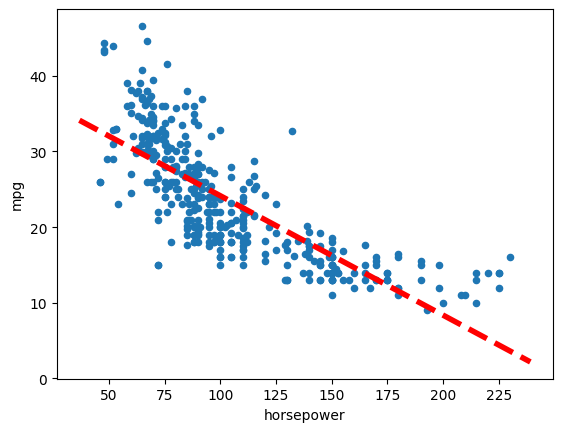

In [7]:
def abline(ax, b, m, *args, **kwargs):
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b ]
    ax.plot(xlim, ylim, *args, **kwargs)

ax = Auto.plot.scatter('horsepower', 'mpg')

abline(ax,
       resultados.params['intercept'],
       resultados.params['horsepower'],
       c='r',
       ls='--',
       linewidth=4)

In [8]:
def imprimir_estatisticas(res):
    print('RSS:', res.ssr)
    print('RSE:', np.sqrt(res.scale))
    print('σ²:', res.scale)
    print('R2:', res.rsquared)

imprimir_estatisticas(resultados)

RSS: 9385.91587193242
RSE: 4.90575691954594
σ²: 24.066450953672874
R2: 0.6059482578894348


In [9]:
resultados.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Tue, 12 May 2026   Prob (F-statistic):           7.03e-81
Time:                        10:21:21   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(c) Produce some of diagnostic plots of the least squares regression
fit as described in the lab. Comment on any problems you see
with the fit.

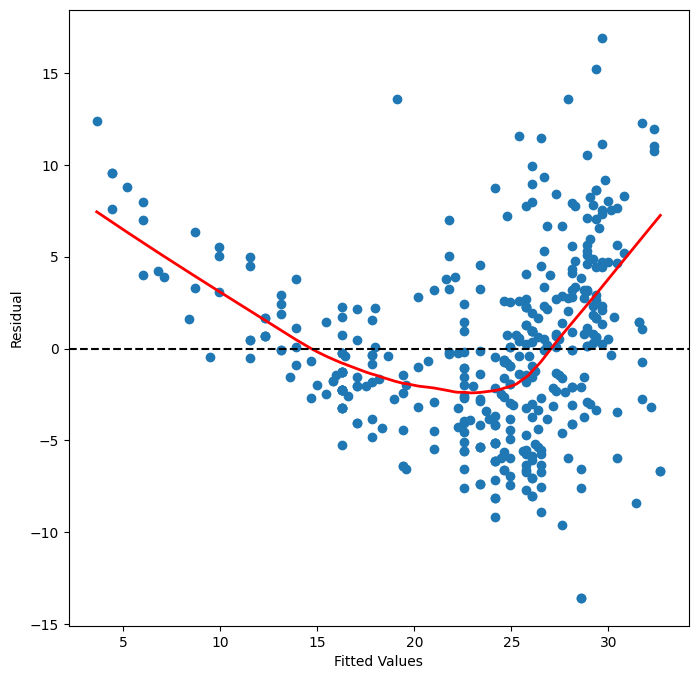

In [10]:
def plot_residuos_valores(res):
    ax = subplots(figsize=(8, 8))[1]
    ax.scatter(res.fittedvalues, res.resid)
    ax.set_xlabel('Fitted Values')
    ax.set_ylabel('Residual')
    lowess = sm.nonparametric.lowess(res.resid, res.fittedvalues)
    ax.plot(lowess[:,0], lowess[:,1], color='red', lw=2)
    ax.axhline(0, c='k', ls='--')

plot_residuos_valores(resultados)

In [11]:
resultados.get_influence?

Signature: resultados.get_influence()
Docstring:
Calculate influence and outlier measures.

Returns
-------
OLSInfluence
    The instance containing methods to calculate the main influence and
    outlier measures for the OLS regression.

See Also
--------
statsmodels.stats.outliers_influence.OLSInfluence
    A class that exposes methods to examine observation influence.
File:      c:\users\olive\.conda\envs\islp\lib\site-packages\statsmodels\regression\linear_model.py
Type:      method

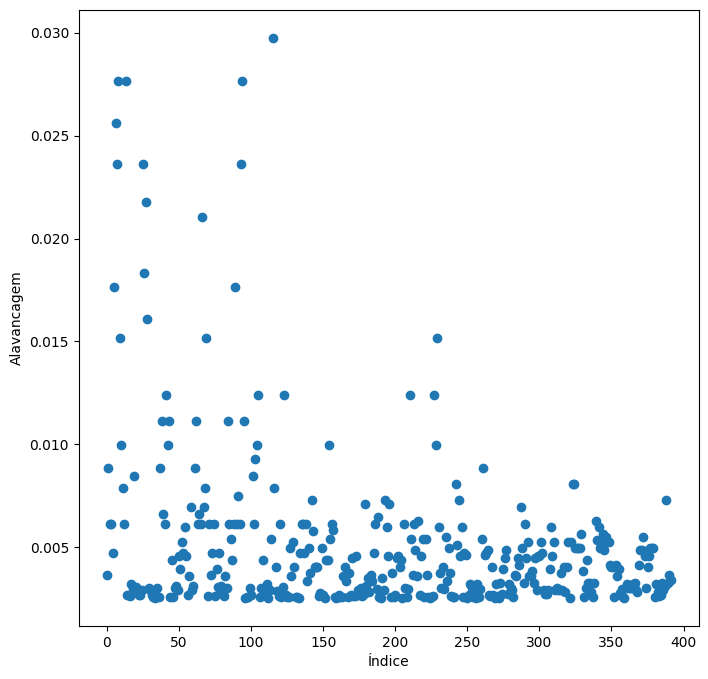

In [12]:
def plot_hat_matrix_diag(res):
    infl = resultados.get_influence()
    ax = subplots(figsize=(8, 8))[1]
    ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
    ax.set_xlabel('Índice')
    ax.set_ylabel('Alavancagem')
    np.argmax(infl.hat_matrix_diag)

plot_hat_matrix_diag(resultados)

9. This question involves the use of multiple linear regression on the
Auto data set.

(a) Produce a scatterplot matrix which includes all of the variables
in the data set.

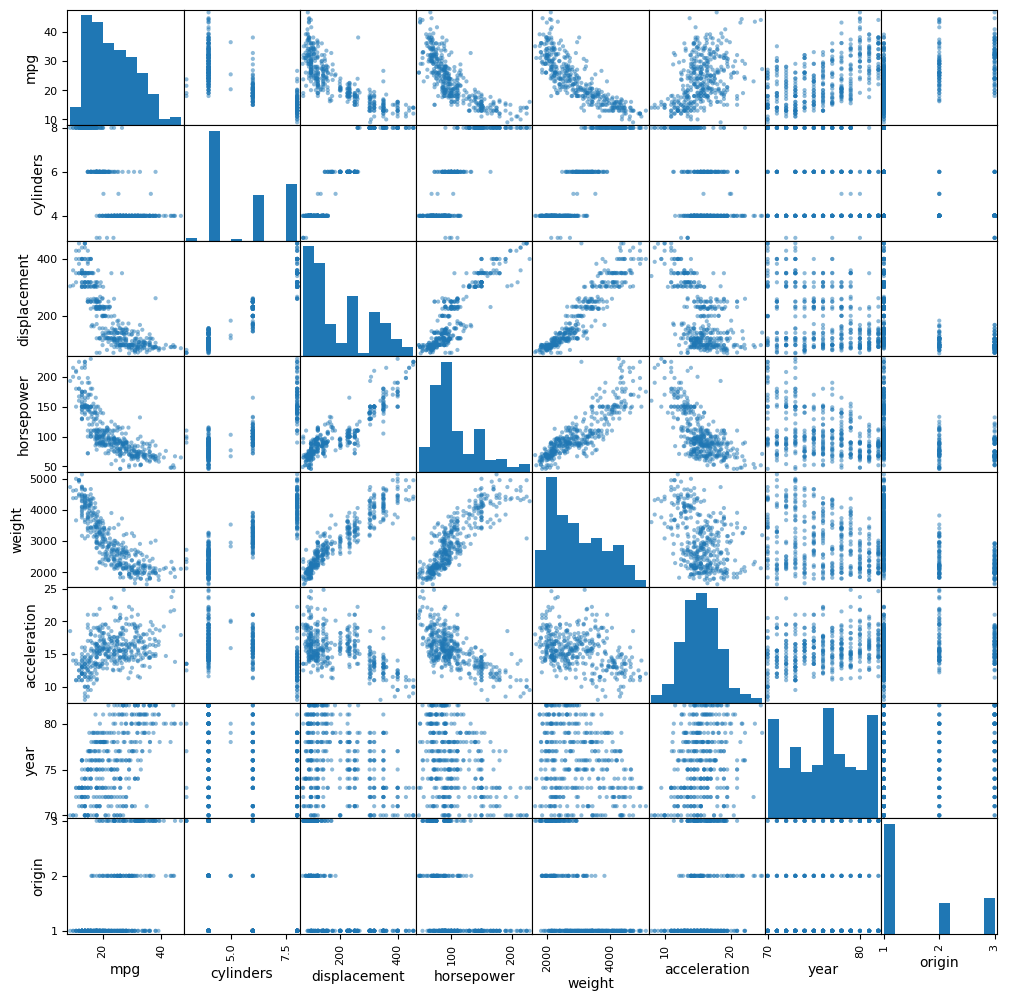

In [13]:
pd.plotting.scatter_matrix(Auto, figsize=(12, 12));

(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.

In [14]:
Auto.corr(numeric_only=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:

In [15]:
colunas = list(Auto.columns.drop(['mpg', 'name']))
X = MS(colunas).fit_transform(Auto)
y = Auto['mpg']
modelo_multi = sm.OLS(y, X)
resultados_multi = modelo_multi.fit()
imprimir_estatisticas(resultados_multi)
summarize(resultados_multi)

RSS: 4252.212530440175
RSE: 3.327682396406638
σ²: 11.073470131354624
R2: 0.8214780764810599


,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [16]:
resultados_multi.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Tue, 12 May 2026   Prob (F-statistic):          2.04e-139
Time:                        10:21:23   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      -17.2184      4.644     -3.707      0.000     -26.350      -8.087
cylinders       -0.4934      0.323     -1.526      0.128      -1.129       0.142
displacement     0.0199      0.008      2.647      0.008       0.005       0.035
horsepower      -0.0170      0.014     -1.230      0.220      -0.044       0.010
weight          -0.0065      0.001     -9.929      0.000      -0.008      -0.005
acceleration     0.0806      0.099      0.815      0.415      -0.114       0.275
year             0.7508      0.051     14.729      0.000       0.651       0.851
origin           1.4261      0.278      5.127      0.000       0.879       1.973
==============================================================================
Omnibus:                       31.906   Durbin-Watson:                   1.309
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.100
Skew:                           0.529   Prob(JB):                     2.95e-12
Kurtosis:                       4.460   Cond. No.                     8.59e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.59e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

i. Is there a relationship between the predictors and the re
sponse? Use the anova_lm() function from statsmodels to
answer this question.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm 

anova_lm(resultados, resultados_multi)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,384.0,4252.212530,6.0,5133.703341,77.267308,5.376746e-63


ii. Which predictors appear to have a statistically significant
relationship to the response?

iii. What does the coefficient for the year variable suggest?

In [18]:
pd.DataFrame({'p_valor':resultados_multi.pvalues,
              't_valor':resultados_multi.tvalues,
              'coeficiente':resultados_multi.params}).sort_values(by='p_valor', ascending=True)

,p_valor,t_valor,coeficiente
year,3.055983e-39,14.728795,0.750773
weight,7.874953e-21,-9.928787,-0.006474
origin,4.665681e-07,5.127492,1.426140
intercept,2.401841e-04,-3.707438,-17.218435
displacement,8.444649e-03,2.647430,0.019896
cylinders,1.277965e-01,-1.526147,-0.493376
horsepower,2.196328e-01,-1.229512,-0.016951
acceleration,4.154780e-01,0.815174,0.080576


(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?

In [19]:
valores = [VIF(X, i) for i in range(1, X.shape[1])]
pd.DataFrame({'vif':valores}, index=X.columns[1:])


,vif
cylinders,10.737535
displacement,21.836792
horsepower,9.943693
weight,10.831260
acceleration,2.625806
year,1.244952
origin,1.772386


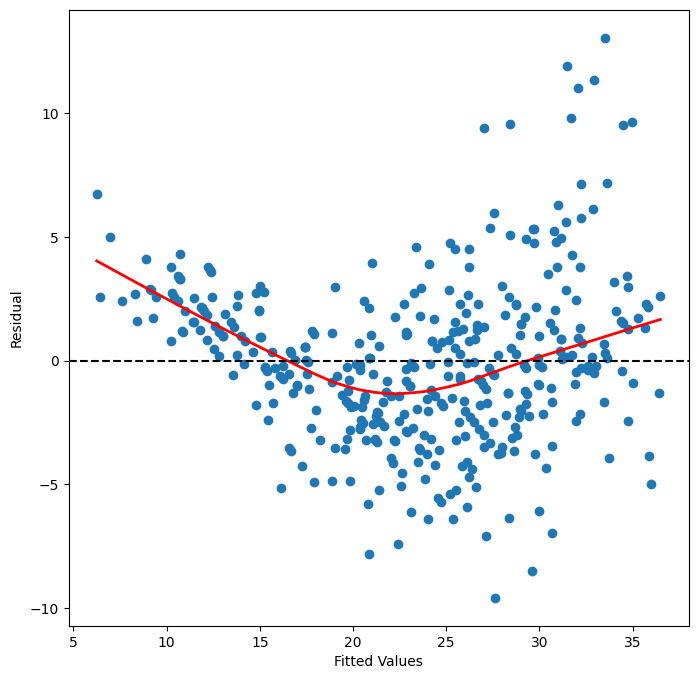

In [20]:
plot_residuos_valores(resultados_multi)

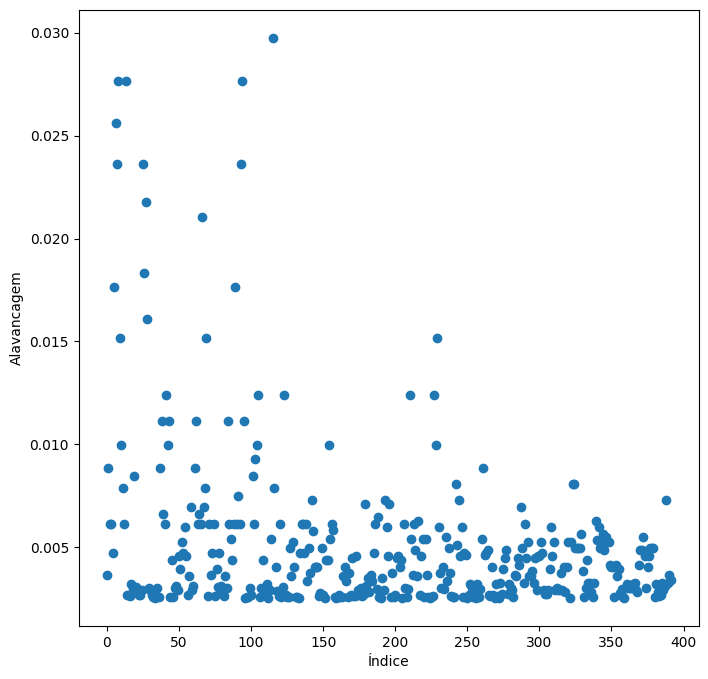

In [21]:
plot_hat_matrix_diag(resultados_multi)

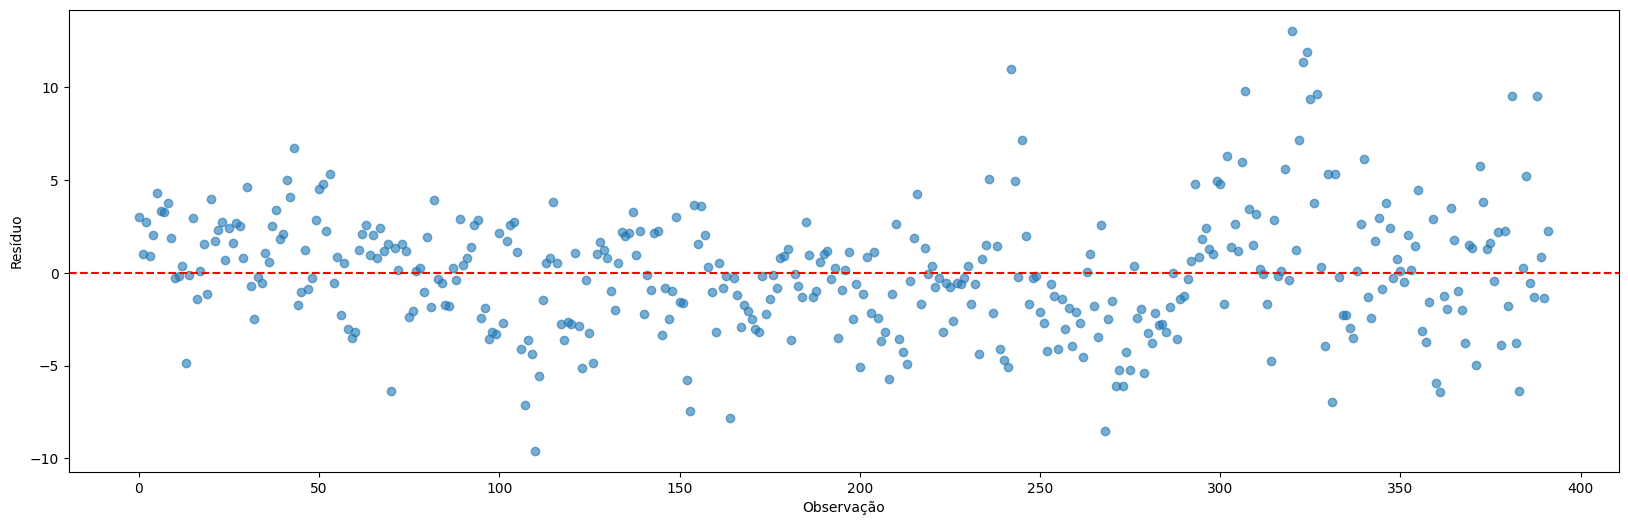

In [22]:
def plot_analise_residuos(r):
    ax = subplots(figsize=(20,6))[1]
    ax.scatter(range(len(r.resid)), r.resid, alpha=0.6)
    ax.set_xlabel('Observação')
    ax.set_ylabel('Resíduo')
    ax.axhline(0, c='r', ls='--')

plot_analise_residuos(resultados_multi)

(d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

In [23]:
colunas_interacao = colunas + [('acceleration','horsepower'),
                               ('cylinders', 'displacement'),
                               ('cylinders', 'horsepower'),
                               ('weight','horsepower'),
                               ('weight', 'acceleration'),
                               ('origin', 'acceleration'),
                               ('origin', 'displacement'),
                               ('year', 'horsepower'),
                               ('year', 'horsepower', 'weight')]
X = MS(colunas_interacao).fit_transform(Auto)
modelo_interacao = sm.OLS(y, X)
resultados_interacao = modelo_interacao.fit()
imprimir_estatisticas(resultados_interacao) 
summarize(resultados_interacao)

RSS: 2786.656962792384
RSE: 2.7260016937105935
σ²: 7.4310852341130245
R2: 0.8830069387115873


,coef,std err,t,P>|t|
intercept,-70.739000,24.497000,-2.888,0.004
cylinders,1.594400,1.001000,1.593,0.112
displacement,-0.080900,0.023000,-3.549,0.000
horsepower,1.348500,0.433000,3.116,0.002
weight,-0.014200,0.003000,-4.423,0.000
acceleration,-1.001500,0.419000,-2.388,0.017
year,1.934600,0.281000,6.873,0.000
origin,-9.356200,2.292000,-4.083,0.000
acceleration:horsepower,-0.003100,0.003000,-1.153,0.250
cylinders:displacement,0.007700,0.003000,2.707,0.007


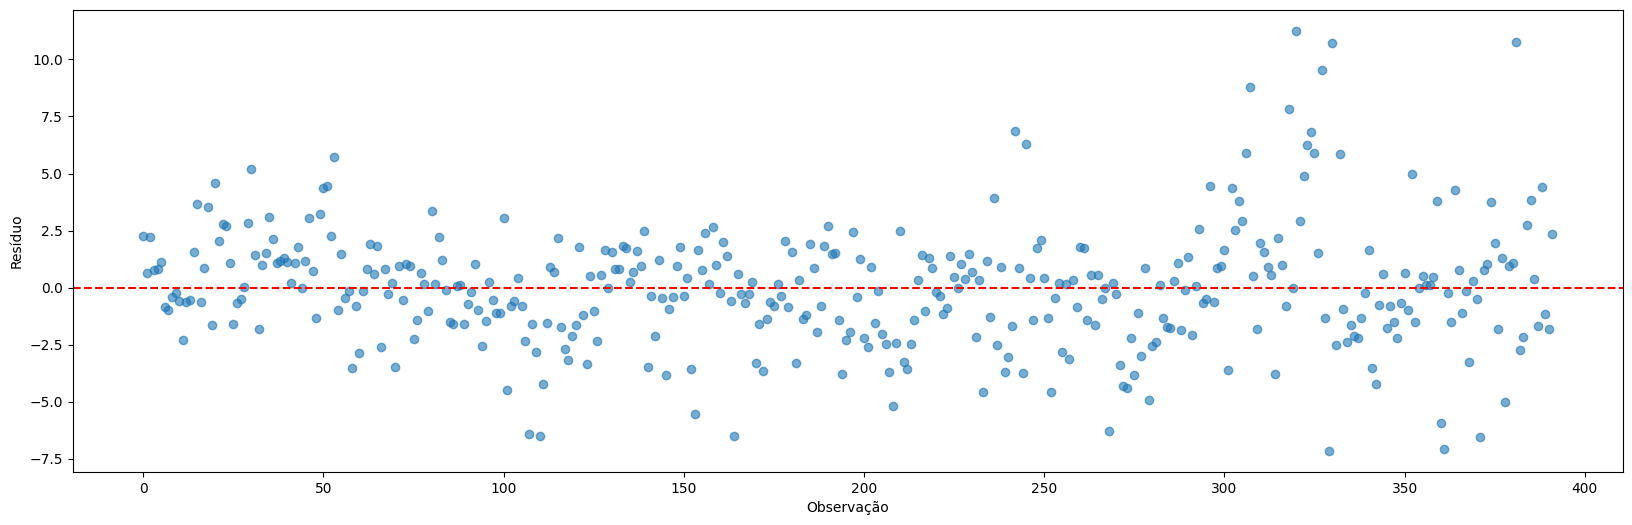

In [24]:
plot_analise_residuos(resultados_interacao)

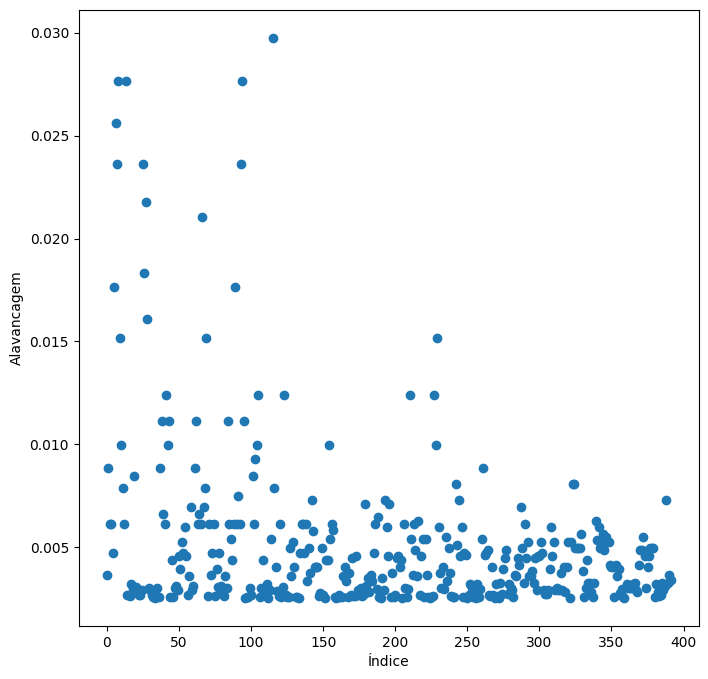

In [25]:
plot_hat_matrix_diag(resultados_interacao)

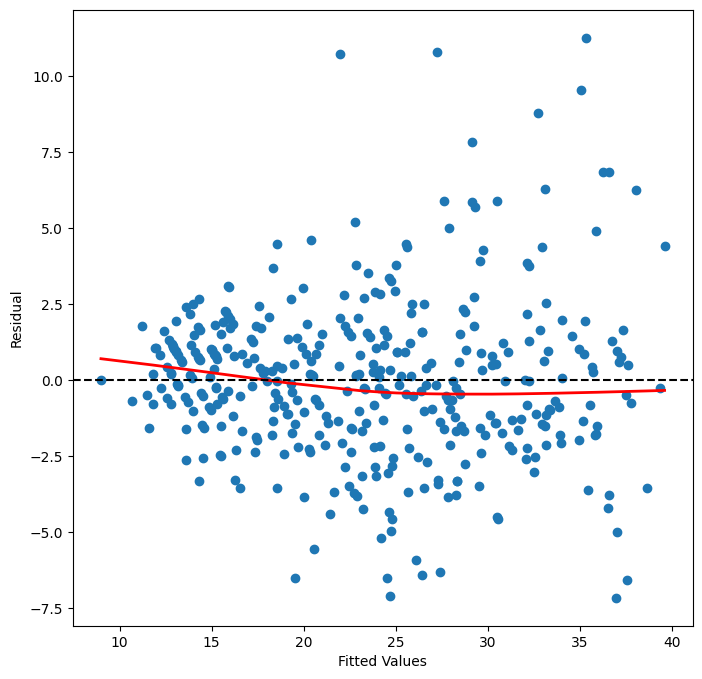

In [26]:
plot_residuos_valores(resultados_interacao)

(f) Try a few different transformations of the variables, such as
log(X), √X, X2. Comment on your findings

In [69]:
colunas_interacao_n_linear = colunas + [poly('year', degree=3),
                               poly('cylinders', degree=3),
                               poly('displacement', degree=3),
                               ('cylinders', 'displacement'),
                               ('cylinders', 'horsepower'),
                               ('origin', 'acceleration'),
                               ('origin', 'displacement'),
                               ('year', 'horsepower'),
                               ('year', 'horsepower', 'weight')]

X = MS(colunas_interacao_n_linear).fit_transform(Auto)
def transformar_X_raiz(X, preditores):
    for preditor in preditores:
        X[f'sqrt_{preditor}'] = np.sqrt(X[preditor])

transformar_X_raiz(X, ['weight'])

def transformar_X_quadrado(X, preditores):
    for preditor in preditores:
        X[f'{preditor}²'] = X[preditor]**2

transformar_X_quadrado(X, ['displacement'])
modelo_interacao_n_linear = sm.OLS(y, X)
resultados_interacao_n_linear = modelo_interacao_n_linear.fit()
imprimir_estatisticas(resultados_interacao_n_linear)
summarize(resultados_interacao_n_linear)

RSS: 2496.7532647230587
RSE: 2.5941844896555506
σ²: 6.72979316636943
R2: 0.8951780532652694


,coef,std err,t,P>|t|
intercept,-2.126650e+01,1.282600e+01,-1.658,0.098
cylinders,5.808200e+00,3.675000e+00,1.581,0.115
displacement,-2.690000e-02,4.900000e-02,-0.546,0.586
horsepower,4.672000e-01,1.640000e-01,2.847,0.005
weight,-2.500000e-03,8.000000e-03,-0.301,0.763
acceleration,-5.781000e-01,1.750000e-01,-3.311,0.001
year,1.022400e+00,1.690000e-01,6.063,0.000
origin,-6.017600e+00,2.428000e+00,-2.478,0.014
"poly(year, degree=3)[0]",2.219680e+01,1.337700e+01,1.659,0.098
"poly(year, degree=3)[1]",1.339050e+01,3.105000e+00,4.313,0.000


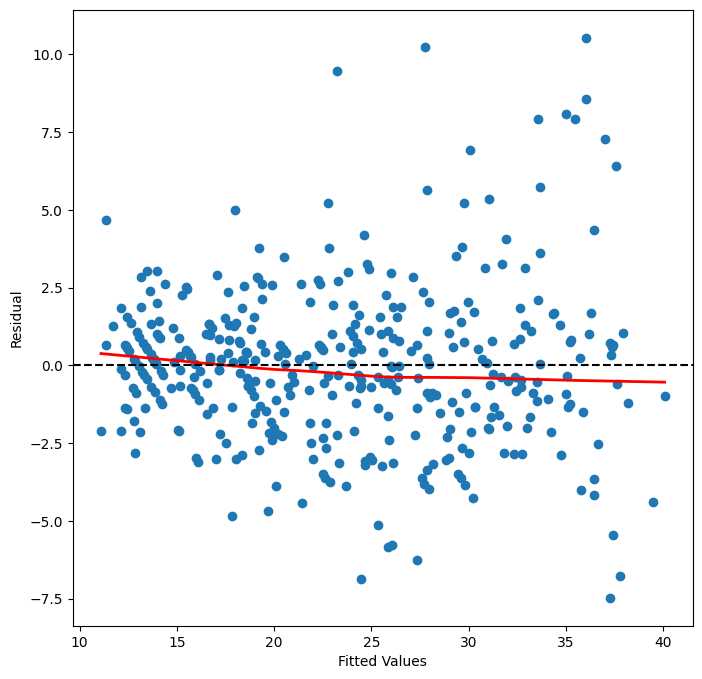

In [70]:
plot_residuos_valores(resultados_interacao_n_linear)

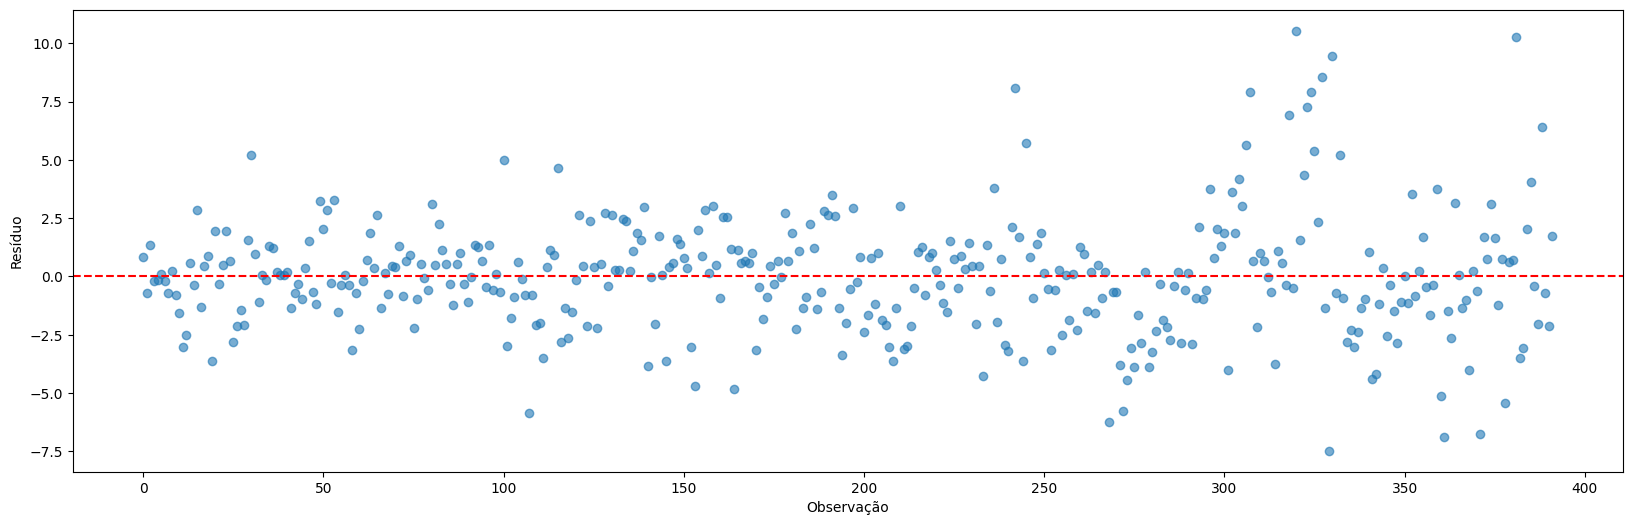

In [71]:
plot_analise_residuos(resultados_interacao_n_linear)

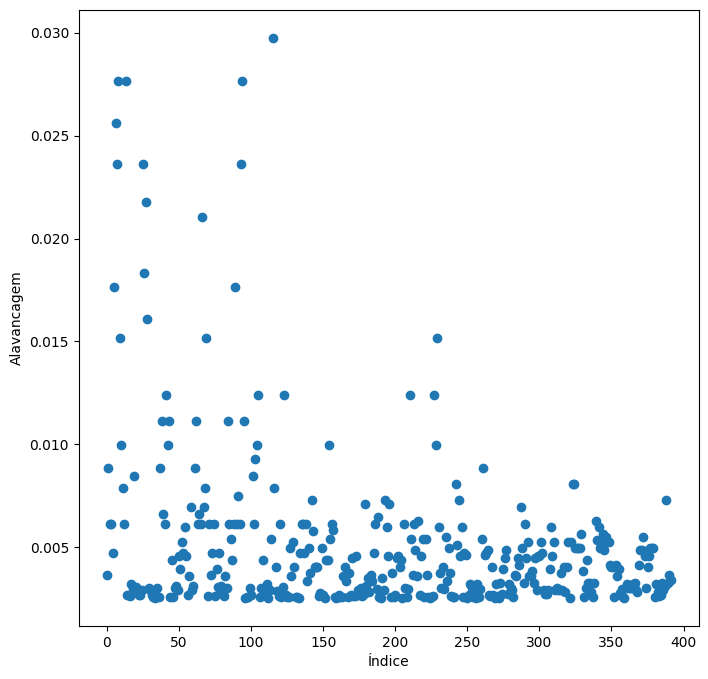

In [72]:
plot_hat_matrix_diag(resultados_interacao_n_linear)

In [75]:
pd.DataFrame({'p_valor':resultados_interacao_n_linear.pvalues,
              't_valor':resultados_interacao_n_linear.tvalues,
              'coeficiente':resultados_interacao_n_linear.params}).sort_values(by='p_valor', ascending=True)

,p_valor,t_valor,coeficiente
year,3.292001e-09,6.062909,1.022423e+00
"poly(year, degree=3)[1]",2.065317e-05,4.313219,1.339051e+01
"poly(year, degree=3)[2]",2.004052e-04,-3.755993,-1.011419e+01
"poly(cylinders, degree=3)[2]",2.285192e-04,3.721733,1.330839e+01
year:horsepower,2.691633e-04,-3.678648,-7.234719e-03
acceleration,1.020113e-03,-3.311209,-5.780673e-01
horsepower,4.660839e-03,2.846855,4.672253e-01
origin:acceleration,8.457821e-03,2.647374,2.748589e-01
"poly(displacement, degree=3)[2]",1.097459e-02,-2.556370,-1.922771e+01
origin,1.365434e-02,-2.478054,-6.017642e+00
